In [32]:
import  tensorflow as tf
print(tf.version.VERSION)

2.22.0-rc0


In [33]:
import glob, os, tarfile

archives = glob.glob("**/*.tar.gz", recursive=True)
print(archives)

arc = archives[0]
print(arc, os.path.getsize(arc), "bytes")

with tarfile.open(arc) as t:
    t.extractall("wisdm")

path = glob.glob("wisdm/**/WISDM_ar_v1.1_raw.txt", recursive=True)[0]
print("Found:", path)

['WISDM_ar_latest.tar.gz']
WISDM_ar_latest.tar.gz 11404612 bytes
Found: wisdm\WISDM_ar_v1.1\WISDM_ar_v1.1_raw.txt


In [34]:
import glob, numpy as np, pandas as pd

# 1. Find and load the WISDM raw file
path = glob.glob("wisdm/**/WISDM_ar_v1.1_raw.txt", recursive=True)[0]
rows = []
with open(path) as f:
    for line in f:
        p = line.strip().rstrip(";").split(",")
        if len(p) == 6:
            try:
                rows.append((int(p[0]), p[1], int(p[2]), float(p[3]), float(p[4]), float(p[5])))
            except ValueError:
                pass

df = pd.DataFrame(rows, columns=["user", "activity", "ts", "x", "y", "z"])
mapping = {"Sitting": "Stationary", "Standing": "Stationary",
           "Walking": "Walking", "Jogging": "Running"}
df = df[df.activity.isin(mapping)].copy()
df["label"] = df.activity.map(mapping)
print(len(df), "rows")

# 2. Build x_recordings / y_recordings
labels = ['stationary', 'walking', 'running']
label_to_idx = {'Stationary': 0, 'Walking': 1, 'Running': 2}

REC_LEN = 300
MAX_PER_CLASS = 40
MS2_TO_MG = 1000 / 9.80665

rng = np.random.default_rng(0)
x_recordings, y_recordings, recordings_filenames = [], [], []

for cls_name, cls_idx in label_to_idx.items():
    recs = []
    sub = df[df.label == cls_name]
    for (user, act), g in sub.groupby(["user", "activity"], sort=False):
        arr = g[["x", "y", "z"]].to_numpy(dtype=np.float32) * MS2_TO_MG
        for s in range(0, len(arr) - REC_LEN + 1, REC_LEN):
            recs.append((arr[s:s+REC_LEN], f"user{user}_{act}_{s}"))
    pick = rng.permutation(len(recs))[:MAX_PER_CLASS]
    for j in pick:
        x_recordings.append(recs[j][0])
        y_recordings.append(cls_idx)
        recordings_filenames.append(recs[j][1])

x_recordings = np.array(x_recordings)
y_recordings = np.array(y_recordings)

print(x_recordings.shape)
print(y_recordings.shape)
print(np.bincount(y_recordings))

863171 rows
(120, 300, 3)
(120,)
[40 40 40]


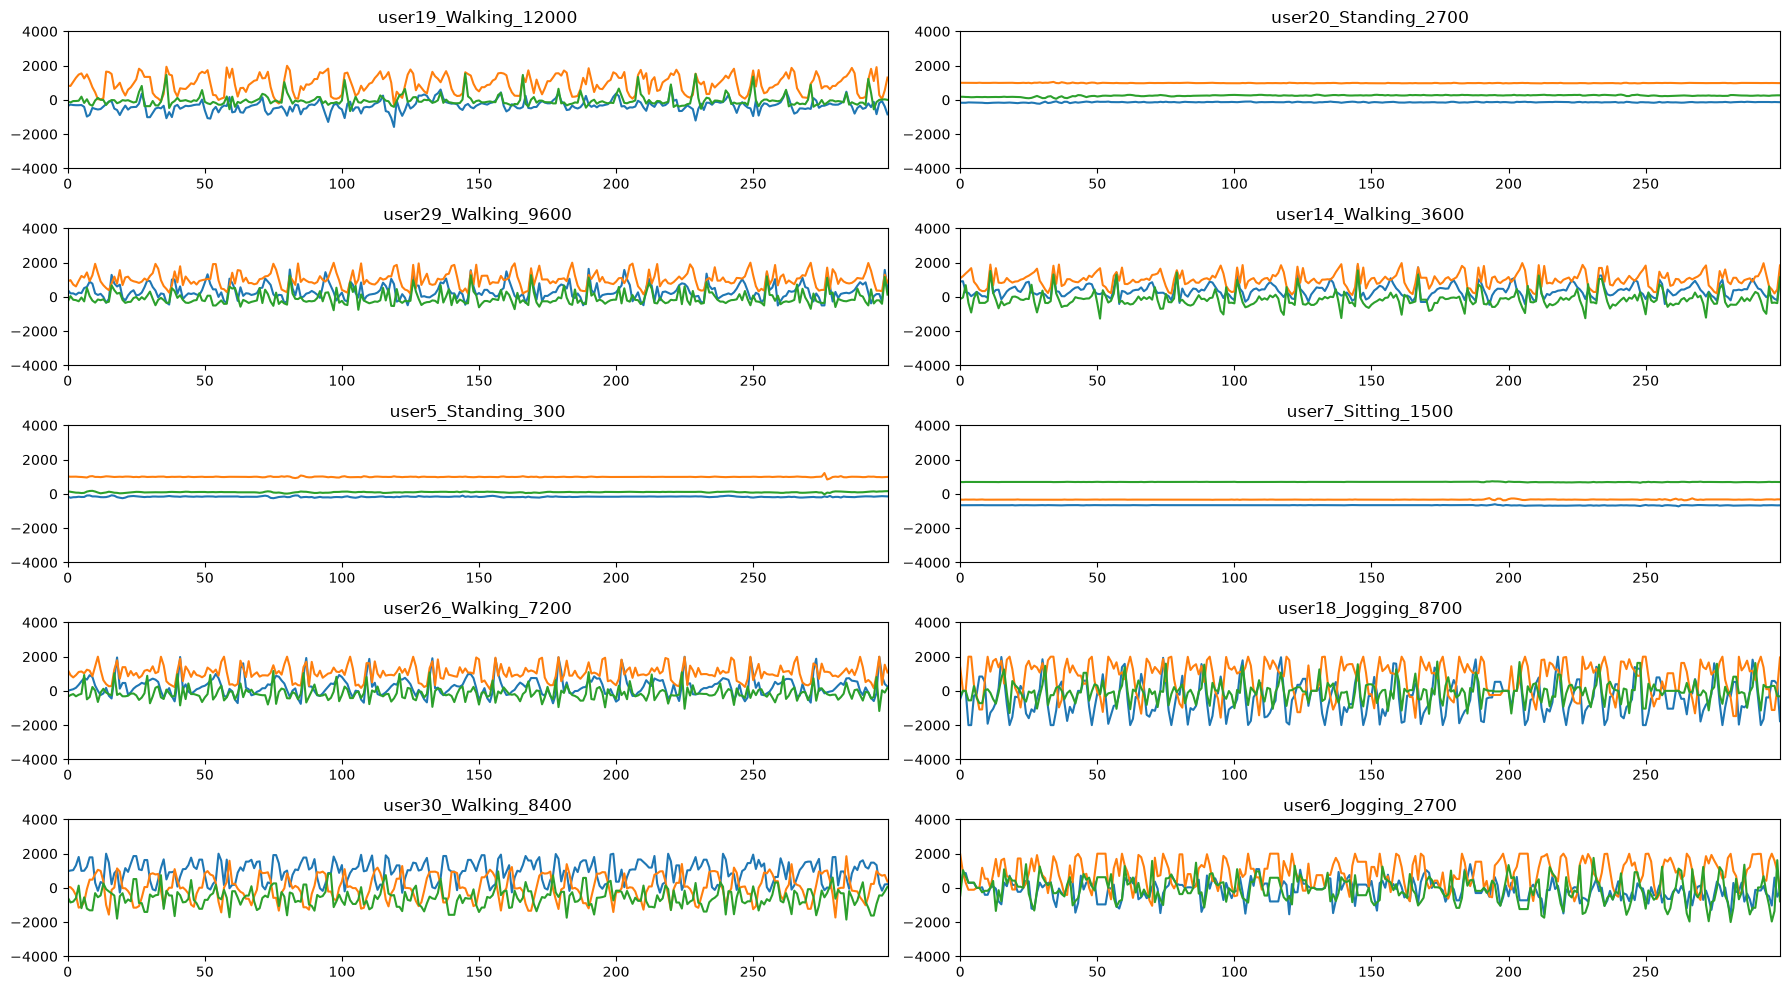

In [35]:
import random
import matplotlib.pyplot as plt
%matplotlib inline

# Plot some captures
random.seed(10)
unique_rands = random.sample(range(len(x_recordings)), 10)
plt.figure(figsize=(18, 10))
for i, n in enumerate(unique_rands):
    plt.subplot(5, 2, i + 1)
    plt.margins(x=0, y=-0.25)
    plt.plot(x_recordings[n])
    plt.ylim(-4000, 4000)  # 4000 mg acc. range
    plt.title(recordings_filenames[n].split('/')[-1])
plt.tight_layout()
plt.show()

In [36]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

cls_idx = {"Stationary": 0, "Walking": 1, "Running": 2}
ORIG_HZ = 20

def features(frames):
    # frames: (N, L, 3) -> simple stats per axis + magnitude
    mag = np.linalg.norm(frames, axis=2, keepdims=True)
    f = np.concatenate([frames, mag], axis=2)           # (N, L, 4)
    return np.concatenate([f.mean(1), f.std(1), f.min(1), f.max(1)], axis=1)

def build(decim, frame_sec):
    rate = ORIG_HZ // decim
    L = int(frame_sec * rate)
    hop = max(L // 2, 1)
    X, y, u = [], [], []
    for (user, act), g in df.groupby(["user", "label"], sort=False):
        arr = g[["x", "y", "z"]].to_numpy(dtype=np.float32)[::decim]
        if len(arr) < L:
            continue
        w = sliding_window_view(arr, (L, 3))[:, 0][::hop]  # (n, L, 3)
        X.append(features(w)); y += [cls_idx[act]] * len(w); u += [user] * len(w)
    return np.concatenate(X), np.array(y), np.array(u), rate, L

print(f"{'rate':>6} {'frame':>7} {'samples':>8} {'acc':>7} {'macroF1':>8}")
for decim in [1, 2, 4]:                  # 20, 10, 5 Hz
    for frame_sec in [0.5, 1, 2, 3]:
        X, y, u, rate, L = build(decim, frame_sec)
        test = u > 28                    # different users for testing
        clf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                     n_jobs=-1, random_state=0)
        clf.fit(X[~test], y[~test])
        p = clf.predict(X[test])
        print(f"{rate:>4}Hz {frame_sec:>5}s {L:>8} "
              f"{accuracy_score(y[test], p):>7.3f} {f1_score(y[test], p, average='macro'):>8.3f}")

  rate   frame  samples     acc  macroF1
  20Hz   0.5s       10   0.883    0.906
  20Hz     1s       20   0.918    0.934
  20Hz     2s       40   0.920    0.936
  20Hz     3s       60   0.923    0.939
  10Hz   0.5s        5   0.859    0.887
  10Hz     1s       10   0.898    0.919
  10Hz     2s       20   0.915    0.932
  10Hz     3s       30   0.919    0.935
   5Hz   0.5s        2   0.795    0.822
   5Hz     1s        5   0.858    0.887
   5Hz     2s       10   0.882    0.906
   5Hz     3s       15   0.901    0.922


In [38]:
import numpy as np

FRAME_LEN = 20    # 20 samples = 1 second at 20 Hz
HOP_LEN = 10      # 50% overlap (use 20 for no overlap)

def frame(x, frame_len, hop_len):
    assert(x.shape == (len(x), 3))
    assert(x.shape[0] >= frame_len)
    assert(hop_len >= 1)

    n_frames = 1 + (x.shape[0] - frame_len) // hop_len
    shape = (n_frames, frame_len, x.shape[1])
    strides = ((hop_len * x.strides[0],) + x.strides)
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

x_frames = []
y_frames = []
for i in range(x_recordings.shape[0]):
    frames = frame(x_recordings[i], FRAME_LEN, HOP_LEN)
    x_frames.append(frames)
    y_frames.append(np.full(frames.shape[0], y_recordings[i]))

print(np.array(x_frames).shape)
x_frames = np.concatenate(x_frames)
y_frames = np.concatenate(y_frames)
print(x_frames.shape)

# Each output label is an integer between 0 and 2:
print(y_frames.shape)
print(labels)

(120, 29, 20, 3)
(3480, 20, 3)
(3480,)
['stationary', 'walking', 'running']


In [39]:
x_frames_normed =x_frames /2000

In [40]:
import numpy as np
from sklearn.model_selection import train_test_split

# frames per recording (same for all recordings here)
n_per_rec = (x_recordings.shape[1] - FRAME_LEN) // HOP_LEN + 1
groups = np.repeat(np.arange(len(x_recordings)), n_per_rec)
assert len(groups) == len(x_frames_normed)

# split the recordings, stratified so each class stays balanced
rec_ids = np.arange(len(x_recordings))
train_rec, test_rec = train_test_split(
    rec_ids, test_size=0.25, random_state=0, stratify=y_recordings)

train_mask = np.isin(groups, train_rec)
x_train, y_train = x_frames_normed[train_mask], y_frames[train_mask]
x_test,  y_test  = x_frames_normed[~train_mask], y_frames[~train_mask]

print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)

Training samples: (2610, 20, 3)
Testing samples: (870, 20, 3)


In [41]:
import tensorflow as tf

## Conv1D based model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(20, 3)),
    tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu'),
    tf.keras.layers.Conv1D(filters=8, kernel_size=3, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=30)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("Test loss:", test_loss)
print("Test acc:", test_acc)
model.summary()

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5797 - loss: 0.8941
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8176 - loss: 0.4390
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9479 - loss: 0.1766
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9728 - loss: 0.0940
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9766 - loss: 0.0755
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9801 - loss: 0.0621
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9839 - loss: 0.0504
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9847 - loss: 0.0421
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9854 - loss: 0.0426
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858 - loss: 0.0425
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9893 - loss: 0.0355
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9866 - l

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape       ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)         │ (None, 18, 16)     │        160 │
├───────────────────────────┼────────────────────┼────────────┤
│ conv1d_3 (Conv1D)         │ (None, 16, 8)      │        392 │
├───────────────────────────┼────────────────────┼────────────┤
│ dropout_1 (Dropout)       │ (None, 16, 8)      │          0 │
├───────────────────────────┼────────────────────┼────────────┤
│ flatten_1 (Flatten)       │ (None, 128)        │          0 │
├───────────────────────────┼────────────────────┼────────────┤
│ dense_2 (Dense)           │ (None, 64)         │      8,256 │
├───────────────────────────┼────────────────────┼────────────┤
│ dense_3 (Dense)           │ (None, 3)          │        195 │
└───────────────────────────┴────────────────────┴────────────┘

 Total params: 27,011 (105.52 KB)

 Trainable params: 9,003 (35.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,008 (70.35 KB)

In [42]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report

# user id of every frame
n_per_rec = (x_recordings.shape[1] - FRAME_LEN) // HOP_LEN + 1
rec_users = np.array([int(n.split('_')[0].replace('user', '')) for n in recordings_filenames])
frame_users = np.repeat(rec_users, n_per_rec)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
tr, te = next(gss.split(x_frames_normed, y_frames, groups=frame_users))
x_train, y_train = x_frames_normed[tr], y_frames[tr]
x_test,  y_test  = x_frames_normed[te], y_frames[te]

print("users in test:", sorted(set(frame_users[te])))
print("train:", x_train.shape, " test:", x_test.shape)
print("test class counts:", np.bincount(y_test, minlength=3))

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(20, 3)),
    tf.keras.layers.Conv1D(16, 3, activation='relu'),
    tf.keras.layers.Conv1D(8, 3, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=30, validation_data=(x_test, y_test), verbose=2)

pred = model.predict(x_test).argmax(axis=1)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=labels))

users in test: [np.int64(3), np.int64(11), np.int64(12), np.int64(19), np.int64(20), np.int64(23), np.int64(28), np.int64(29), np.int64(34)]
train: (2349, 20, 3)  test: (1131, 20, 3)
test class counts: [406 406 319]
Epoch 1/30
74/74 - 3s - 46ms/step - accuracy: 0.5219 - loss: 0.9451 - val_accuracy: 0.8196 - val_loss: 0.6098
Epoch 2/30
74/74 - 0s - 6ms/step - accuracy: 0.8255 - loss: 0.4789 - val_accuracy: 0.9178 - val_loss: 0.2819
Epoch 3/30
74/74 - 0s - 4ms/step - accuracy: 0.9468 - loss: 0.2051 - val_accuracy: 0.9089 - val_loss: 0.2374
Epoch 4/30
74/74 - 0s - 5ms/step - accuracy: 0.9740 - loss: 0.1114 - val_accuracy: 0.9187 - val_loss: 0.1872
Epoch 5/30
74/74 - 0s - 5ms/step - accuracy: 0.9770 - loss: 0.0824 - val_accuracy: 0.9275 - val_loss: 0.1456
Epoch 6/30
74/74 - 0s - 5ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9178 - val_loss: 0.2335
Epoch 7/30
74/74 - 0s - 5ms/step - accuracy: 0.9885 - loss: 0.0493 - val_accuracy: 0.9178 - val_loss: 0.2225
Epoch 8/30
74/74 - 0

In [43]:
model.save('model.h5')